# 第7章 深入 Keras

## 7.1 Keras 工作流程

Keras API 的设计原则是**渐进式呈现复杂性**（progressive disclosure of complexity）:简单的工作流程应该简单易懂，同时还有高级的工作流程:无论你的问题多么罕见、多么复杂,应该都有一条清晰的解决路径。

## 7.2 构建 Keras 模型的不同方法

- **序贯模型**（sequential model）

- **函数式API**（functional API）

- **模型子类化**（model subclassing）

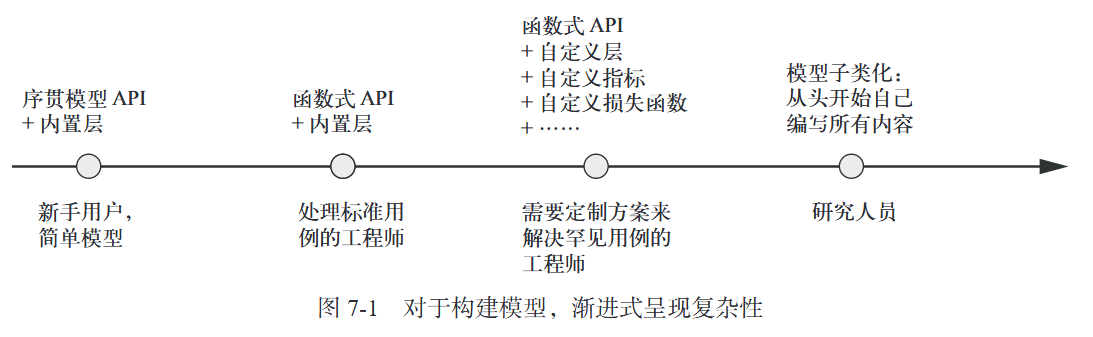

### 7.2.1 序贯模型

代码清单 7-1 Sequential 类

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

2025-02-15 15:14:28.056103: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-02-15 15:14:29.684598: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-02-15 15:14:29.688938: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-02-15 15:14:29.744878: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:927] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-15 15:14:29.744958: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 3060 Laptop GPU computeCapability: 8.6
coreClock: 1.425GHz coreCount: 30 deviceMemorySize: 6.00GiB deviceMemoryBandwidth: 312.97GiB/s
2025-02-15 15:14:29.744985: I tensorflow/stream_exec

代码清单 7-2 逐步构建序贯模型 `add()` 方法

In [2]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

代码清单 7-3 尚未完成构建的模型没有权重

In [ ]:
model.weights

代码清单 7-4 通过第一次调用模型来完成构建

In [3]:
model.build(input_shape=(None, 3))
model.weights

[<tf.Variable 'dense_2/kernel:0' shape=(3, 64) dtype=float32, numpy=
 array([[ 0.07764378,  0.24268293,  0.08599734,  0.2633943 ,  0.26175272,
         -0.18397006,  0.10705662,  0.2932213 ,  0.03062102, -0.0936477 ,
          0.12307075,  0.2671001 , -0.13209462, -0.00976968,  0.08746895,
          0.02127922,  0.22964352,  0.2051099 ,  0.18081328, -0.20889764,
          0.28339922, -0.07448921, -0.27424031, -0.01693487,  0.25885385,
          0.12275845,  0.25958258, -0.15846942,  0.17940581,  0.0009709 ,
          0.23117214, -0.18768798, -0.03214416,  0.01928684, -0.13576703,
         -0.10806274,  0.11695948,  0.01799667, -0.0010722 ,  0.14585185,
          0.21031886,  0.14054444,  0.24431795,  0.1236493 ,  0.0258877 ,
          0.05426672,  0.17952725,  0.14637232, -0.07670513, -0.0500194 ,
          0.13267106,  0.06662166, -0.02264953, -0.03761545,  0.18958104,
         -0.16325219, -0.1524606 ,  0.26087797,  0.15270206,  0.06747547,
          0.2839641 ,  0.07196438, -0.15682

代码清单 7-5 `summary()` 方法

In [4]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 64)                256       
_________________________________________________________________
dense_3 (Dense)              (None, 10)                650       
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


代码清单 7-6 利用 `name` 参数命名模型和层

In [5]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
my_first_layer (Dense)       (None, 64)                256       
_________________________________________________________________
my_last_layer (Dense)        (None, 10)                650       
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


代码清单 7-7 提前声明模型的输入形状

In [6]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

代码清单 7-8 使用 `summary()` 跟踪模型输出形状的变化

In [7]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 64)                256       
Total params: 256
Trainable params: 256
Non-trainable params: 0
_________________________________________________________________


In [8]:
model.add(layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 64)                256       
_________________________________________________________________
dense_5 (Dense)              (None, 10)                650       
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


### 7.2.2 函数式 API

#### 1. 简单示例

代码清单 7-9 带有两个 Dense 层的简单函数式模型

In [9]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

#### 2. 多输入、多输出模型

代码清单 7-19 多输入、多输出的函数式模型

In [10]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")
# 通过拼接将输入特征组合成张量 features
features = layers.Concatenate()(([title, text_body, tags]))
# 利用中间层，将输入特征重组为更加丰富的表示
features = layers.Dense(64, activation="relu")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department")(features)

model = keras.Model(inputs=[title, text_body, tags],
                    outputs=[priority, department])

#### 3. 训练一个多输入、多输出模型

代码清单 7-11 通过给订输入和目标组成的列表来训练模型

In [ ]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])
model.fit([title_data, text_body_data, tags_data],
          [priority_data, department_data])
priority_prids, department_preds = model.predict(
    [title_data, text_body_data, tags_data]
)


代码清单 7-12 通过给定输入和目标组成的字典来训练模型

In [ ]:
model.compile(optimizer="rmsprop",
              loss={"priority": "mean_sequared_error",
                    "department": "categorical_crossentropy"},
              metrics={"priority":["mean_absolute_error"],
                       "department": ["accuracy"]})
model.fit({"title": title_data,"text_body": text_body_data,
           "tags": tags_data},
          {"priority": priority_data, "department": department_data},
          epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data,
                "tags": tags_data},
               {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})


#### 4. 函数式 API 的强大之处：获取层的连接方式

可以用 `plot_model()` 将函数式模型绘制成图。

In [ ]:
keras.utils.plot_model(model, "ticket_classifier.png")

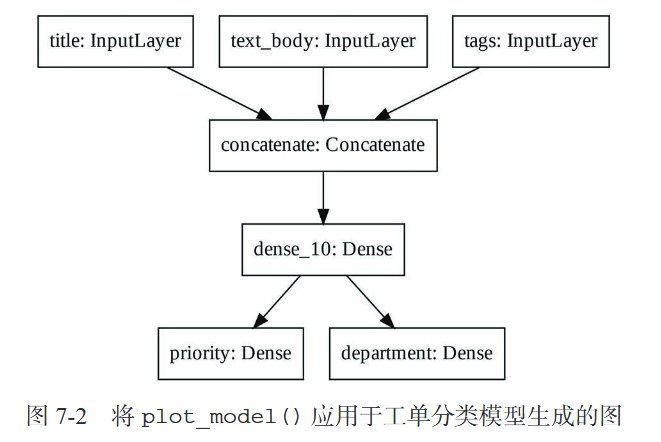

代码清单 7-13 检索函数式模型某一层的输入或输出

In [ ]:
model.layers

In [ ]:
model.layers[3].input

In [ ]:
model.layers[3].output

代码清单 7-14 重复使用中间层的输出，创建一个新模型

In [ ]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difculty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department, difficulty]
)

keras.utils.plot_model(
    new_model, "updated_ticket_classifier.png", show_shapes=True
)

### 7.2.3 模型子类化

#### 1. 将前一个例子重新实现为 Model 子类

代码清单 7-15 简单的子类化模型

In [2]:
class CustomerTicketModel(keras.Model):
    
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, action="softmax"
        )
        
    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]
        
        featurs = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return pirority, department

NameError: name 'keras' is not defined

#### 2. 子类化模型不能做什么

对于子类化模型，需要负责更多的模型逻辑，犯错的可能性也更大。

由于层与层之间的连接方式隐藏在 `call()` 方法中， `summary()`、`plot_model()` 等方法无法被调用。

### 7.2.4 混合使用不同的组件

代码清单 7-16 创建一个包含子类化模型的函数式模型

In [ ]:
class Classifier(keras.Model):
    
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_unit = num_classes
            activation = "softmax"
        self.dense = layers.Dense(num_units, activation=activation)
        
    def call(self, inputs):
        return self.dense(inputs)
    
inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

代码清单 7-17 创建一个包含函数式模型的子类化模型

In [ ]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.clasifier = binary_classifier
        
    def call(self.inputs):
        features = self.dense(inputs)
        return self.classifier(features)
    
model = MyModel()

### 7.2.5 用正确的工具完成工作

## 7.3 使用内置的训练循环和评估循环

代码清单 7-18 标准工作流程 `compile()`、`fit()`、`evaluate()`、`predict()`

In [ ]:
from tensorflow.keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28, ))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

### 7.3.1 编写自定义指标

代码清单 7-19 通过将 Metric 类子类来实现自定义指标

In [ ]:
import tensorflow as tf

class RootMeanSquaredError(kerase.metrics.Metric):
    
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros", dtype="int32")
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[1])
        mse = tf.reduce_sum(tf.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = tf.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)
        
    def result(self):
        return tf.sqrt(self.mse_sum / tf.cast(self.total_samples, tf.float32))
    
    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0)

In [ ]:
model =get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy", RootMeanSquaredError])
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels)

### 7.3.2 使用回调函数

Keras 的**回调函数**（callback） API 可以实时监控 `model.fit()` 运行过程中的运行情况，并采取一些行动：终端训练、保存模型、加载一组不同的权重或者改变模型状态。

`keras.callbacks` 模块包含许多内置的回调函数：

```python
keras.callbacks.ModelCheckpoint
keras.callbacks.EarlyStopping
keras.callbacks.LearningRateScheduler
keras.callbacks.ReduceLROnPlateau
keras.callbacks.CSVLogger
```

代码清单 7-20 在 `fit()` 方法中使用 `callbacks` 参数

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="vval_accuracy",
        patience=2
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    )
]
model = get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=callbacks_list,
          validation_data=(val_images, val_labels))
model = keras.models.load_model("checkpoint_path.keras")

### 7.3.3 编写自定义回调函数

代码清单 7-21 通过 `Callback` 类子类化来创建自定义回调函数

In [ ]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []
    
    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))
        
    def one_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
                 label="Training loss for each batch")
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}")
        self.per_batch_losses = []   

In [ ]:
model = get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=[LossHistory()],
          validation_data=(val_images, val_labels))

### 7.3.4 利用 TensorBoard 进行监控和可视化

首先,你有一个想法,并将其表述为一个实验，用于验证你的想法是否正确；然后，你运行这个实验并处理生成的信息；这又激发了你的下一个想法。

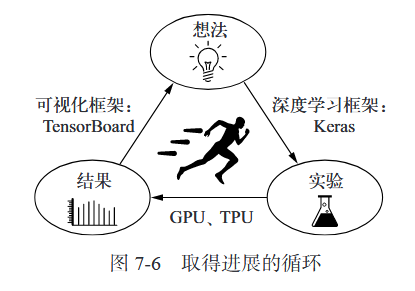

TensorBoard 是一个基于浏览器的应用程序，可以本地运行。利用 TensorBoard，可以做以下工作：

- 在训练过程中以可视化方式监控指标；
- 将模型架构可视化；
- 将激活函数和梯度直方图可视化
- 以三维形式研究嵌入

在最简单的情况下，只需指定让回调函数写入日志的位置即可。

In [ ]:
model = get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
tensorboard = keras.callbacks.TensorBoard(
    log_dir="/  f  ull_path_to_your_log_dir",
    ) 
model.fit(train_images, train_labels,
          epochs=10,
          validation_data=(val_images, val_labels),
          callbacks=[tensorboard])

在命令行运行：

```bash
tensorboard --logdir /full_path_to_your_log_dir
```

即可在浏览器中查看训练过程中监控的参数了。

也可以用如下命令，将 TensorBoard 嵌入式实例作为笔记本的一部分。

```python
%load_ext tensorboard
%tensorboard --logdir /full_path_to_your_log_dir
```

## 7.4 编写自定义的训练循环和评估循环

内置的 `fit()` 工作流程只针对于**监督学习**（supervised learning, 已知与输入数据相关两的**目标**）。然而，并非所有机器学习任务都属于这个类别。比如：

- **生成式学习**（generative learning）
- **自监督学习**（self-supervised learning，**目标**是从输入中获取的）
- **强化学习**（reinforcement learning，学习由偶尔的“奖励”驱动）

如果内置的 `fit()` 不够用，就需要编写自定义的训练逻辑。

### 7.4.1 训练与推断

层和模型具有以下两种权重。

- **可训练权重**（trainable weight）：Dense 层的核和偏置

- **不可训练权重**（non-trainable weight）：批量

### 7.4.2 指标的低阶用法

### 7.4.3 完整的训练循环和评估循环

代码清单 7-22 逐步编写训练循环：训练步骤函数

In [ ]:
model = get_mnist_model()

# 准备损失函数
loss_fn = keras.losses.SparseCategoricalCrossentropy()
# 准备优化器
optimizer = keras.optimizers.RMSprop()
# 准备需监控的指标列表
metrics = [keras.metrics.SparseCategoricalAccuracy()]
# 准备 Mean 指标的跟踪器来跟踪损失均值
loss_tracking_metric = keras.metrics.Mean()

def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs[metric.name] = metric.result()
        
        loss_tracking_metric.update_state(loss)
        logs["loss"] = loss_tracking_metric.result()
        return logs

代码清单 7-23 逐步编写训练循环：重置指标

In [ ]:
def reset_metrics():
    for metric in metrics:
        metric.reset_state()
    loss_tracking_metric.reset_state()

代码清单 7-24 逐步编写训练循环：循环本身

In [ ]:
training_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels))
training_dataset = training_dataset.batch(32)
epochs = 3
for epoch in range(epochs):
    reset_metrics()
    for inputs_batch, targets_batch in training_dataset:
        logs = train_step(inputs_batch, targets_batch)
    print(f"Results at the end of epoch {epoch}")
    for key, value in logs.items():
        print(f"...{key}: {value:.4f}")

代码清单 7-25 逐步编写评估循环

In [ ]:
def test_step(inputs, targets):
    predictions = model(inputs, training=False)
    loss = loss_fn(targets, predictions)
    
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs["val_" + metric.name] = metric.result()
        
    loss_tracking_metric.update_state(loss)
    logs["val_loss"] = loss_tracking_metric.result()
    return logs

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(32)
reset_metrics()
for inputs_batch, targets_batch in val_dataset:
    logs = test_step(inputs_batch, targets_batch)
print("Evaluation results:")
for key, value in logs.items():
    print(f"...{key}: {value:.4f}")

### 7.4.4 利用 `tf.function` 加速快行速度

默认情况下， TensorFlow 代码是逐行**急切执行**的，即代码是一行一行执行的。一种优化策略是，把所有的代码绘制成一个**计算图**，在总体上进行优化后在执行。实现这种优化策略的方法是添加 `@tf.function` 修饰器。

代码清单 7-26 为评估步骤函数添加 `@tf.function` 装饰器

In [ ]:
@rf.Function
def test_step(inputs, targets):
    predictions = model(inputs, training=False)
    loss = loss_fn(targets, predictions)
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs["val_" + metric.name] = metric.result()
        loss_tracking_metric.update_state(loss)
        logs["val_loss"] = loss_tracking_metric.result()
        return logs
    
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(32)
reset_metrics()
for inputs_batch, targets_batch in val_dataset:
    logs = test_step(inputs_batch, targets_batch)
print("Evaluation results:")
for key, value in logs.items():
    print(f"...{key}: {value:.4f}")

### 7.4.5 在 `fit()` 中使用自定义训练循环

覆盖 `Model` 类的 `train_step()` 方法自定义训练算法。

代码清单 7-27 实现自定义训练步骤,并与 `fit()` 结合使用

In [ ]:
loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = loss_fn(targets, predictions)
            gradients = tape.gradient(loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
            loss_tracker.update_state(loss)
            return {"loss": loss_tracker.result()}
    @property
    def metrics(self):
        return [loss_tracker]